<a href="https://colab.research.google.com/github/minoshim/Num_Analysis/blob/main/FDS/Py/Adv/fds_adv.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Simulation end at t = 0.150000


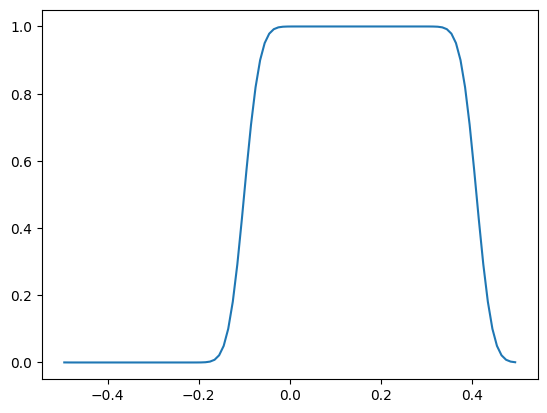

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# User-set parameters
## Spatial grid
xoff=2
xmesh=100
nx=xmesh+2*xoff
## Domain size, advection velocity, CFL number
lx=1.0
v=1.0
cfl=0.5
## Simulation time
tmax=0.15
# End of user-set parameters

# Grid width
dx=lx/xmesh
dt=np.abs(cfl*dx/v)
# Variables
x=np.zeros(nx)
f=np.zeros(nx)

# Functions
def init(x,f):                  # Initialize
    nx=len(f)
    i=np.arange(nx)
    x[:]=(i+0.5-xoff)*dx-0.5*lx
    f[:]=np.where((nx//4 < i) & (i < 3*nx//4), 1.0, 0.0)
    # f[:]=np.exp(-(x[:]*x[:])/(16*dx*dx))

def bc1d(f,xoff,dnx=0):         # Boundary condition
    nx = len(f)
    if dnx == 0:
        f[:xoff] = f[nx - 2*xoff : nx - xoff]
        f[nx - xoff:] = f[xoff : 2*xoff]
    elif abs(dnx) == 1:
        f[:xoff] = dnx * f[xoff : 2*xoff][::-1]
        f[nx - xoff:] = dnx * f[nx - 2*xoff : nx - xoff][::-1]

def ftcs(f,v,dt,dx,xoff=1):       # FTCS scheme
    nx=len(f)
    nu=v*dt/dx
    df=np.zeros_like(f)
    df[1:-1]=0.5*(f[2:]-f[:-2])
    f[xoff:nx-xoff]-=nu*df[xoff:nx-xoff]

def upwd(f,v,dt,dx,xoff=1):       # Upwind scheme
    nx=len(f)
    nu=v*dt/dx
    sgnv=np.sign(v)
    df=np.zeros_like(f)
    df[1:-1]=0.5*((1+sgnv)*(f[1:-1]-f[:-2])+(1-sgnv)*(f[2:]-f[1:-1]))
    f[xoff:nx-xoff]-=nu*df[xoff:nx-xoff]

def main(t,tmax):
    while(t < tmax):
        bc1d(f,xoff,0)
        # ftcs(f,v,dt,dx,xoff)
        upwd(f,v,dt,dx,xoff)
        t += dt
    return t

init(x,f)
t=main(0,tmax)
print(f"Simulation end at t = {t:.6f}")
plt.plot(x[xoff:-xoff],f[xoff:-xoff])
plt.show()